M2: Initial Implementation
Customer Segmentation and Market Basket Analysis

Jia Liu

CS 4412 - Data Mining

Kennesaw State University

Email: jliu43@students.kennesaw.edu

This milestone presents exploratory data analysis (EDA), data preprocessing, and initial pattern discovery using the UCI Online Retail dataset. The goal is to identify meaningful patterns in customer transactions, particularly product co-occurrence relationships, that can support marketing insights such as cross-selling and product bundling strategies. The analysis follows the Knowledge Discovery in Databases (KDD) process.


#1.Environment Setup

In [7]:
!pip install jupyter_client==7.4.9

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [9]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail .xlsx to Online Retail .xlsx


In [11]:
df = pd.read_excel("Online Retail .xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# 3.Dataset Overview

The dataset contains **541,909 transactions** with **8 attributes**.  
Each row represents a product purchased within a transaction.

Features:

• InvoiceNo – transaction identifier  
• StockCode – product identifier  
• Description – product name  
• Quantity – number of items purchased  
• InvoiceDate – transaction timestamp  
• UnitPrice – product price  
• CustomerID – customer identifier  
• Country – customer country

In [13]:
##Data cleaning/ preprocessing
df_clean = df.copy()
df_clean = df_clean.dropna()

df_clean = df_clean[df_clean['Quantity'] > 0]

df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [15]:
print("Clean dataset shape:", df.shape)

Clean dataset shape: (541909, 9)


#5.Exploratory Data Analysis(EDA)


##5.1-1 Quantity Distribution - Raw Data

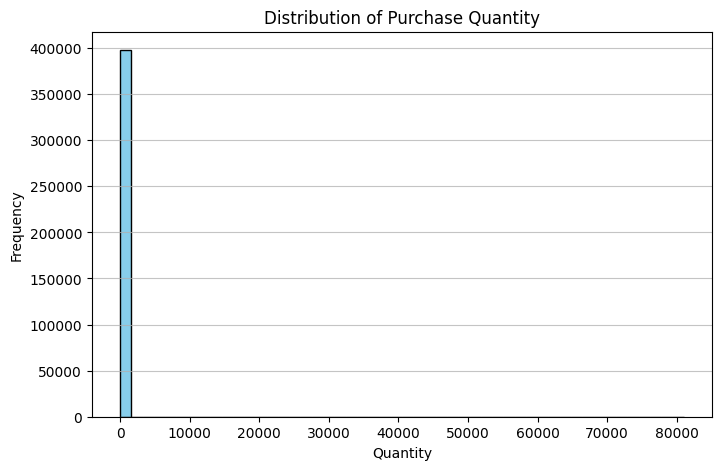

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df_clean['Quantity'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Purchase Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.75)

plt.savefig("quantity_histogram.png")

plt.show()

The original distribution is highly skewed with most values concentrated near zero.


##5.1-2 Quantity Distribution - Filtered Data

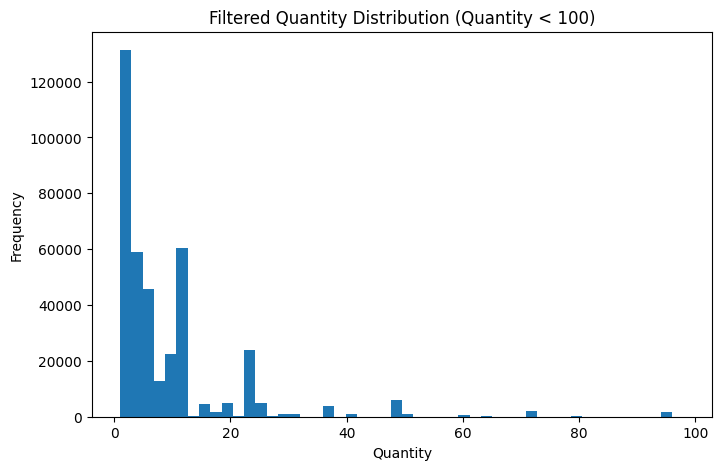

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df_clean[df_clean['Quantity'] < 100]['Quantity'], bins=50)
plt.title("Filtered Quantity Distribution (Quantity < 100)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

After filtering extreme values, the distribution becomes clearer and easier to interpret.

##5.2 Unit Price Distribution

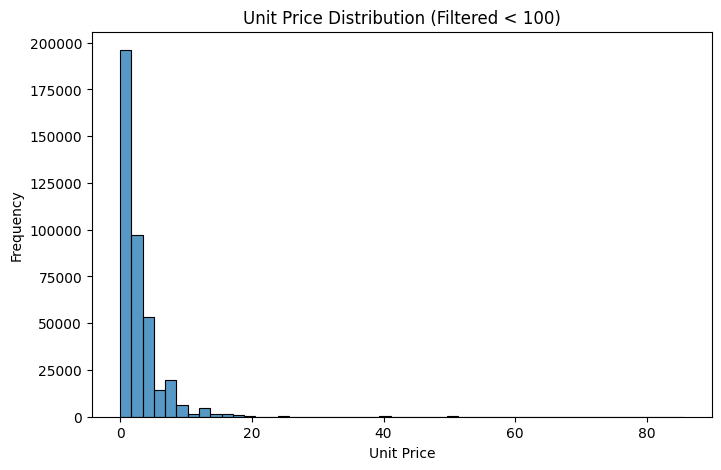

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean[df_clean['UnitPrice'] < 100]['UnitPrice'], bins=50)
plt.title("Unit Price Distribution (Filtered < 100)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

The distribution of unit prices is highly right-skewed. Most products have relatively low prices.In the original data, extreme values compress the histogram, making it hard to observe typical purchasing patterns.After filtering out extreme prices (e.g., keeping only UnitPrice < 100), the distribution becomes much clearer. This filtered view better represents the typical range of product prices and allows us to analyze customer purchasing behavior more accurately.

##5.3 Top 10 Products

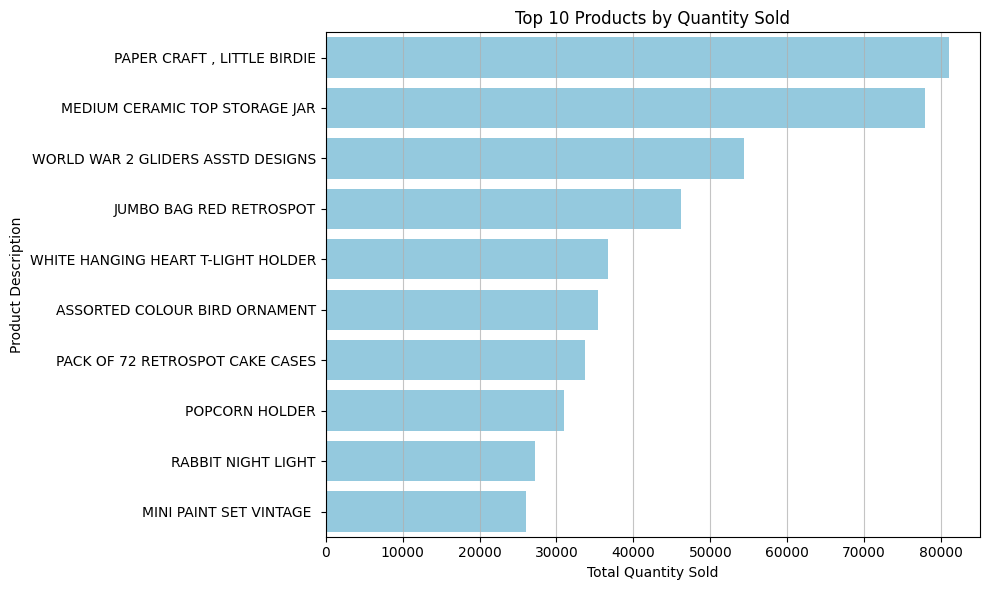

In [19]:
# Top 10 products by total quantity sold
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, color="skyblue")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Description")
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

The top 10 products by quantity sold represent the items that customers purchase most frequently. This analysis highlights which products dominate sales and can help with inventory management, marketing strategies, and product placement. The visualization clearly shows that a small number of products account for a large portion of total sales, consistent with the Pareto principle.

##5.4 Country Distribution

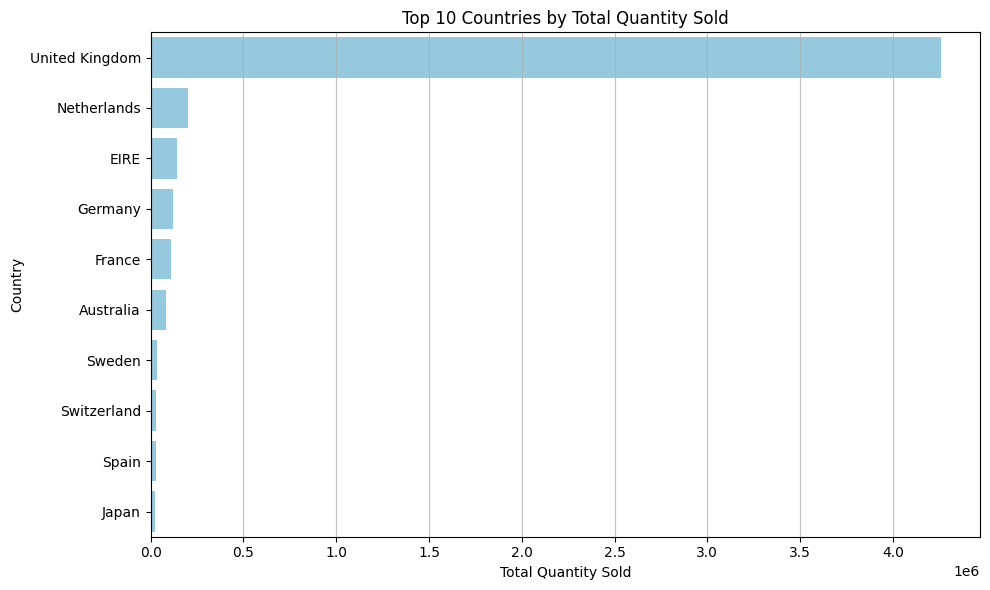

In [20]:
country_sales = df_clean.groupby('Country')['Quantity'].sum().sort_values(ascending=False)
country_sales_top10 = country_sales.head(10)
country_sales_top10

plt.figure(figsize=(10,6))
sns.barplot(x=country_sales_top10.values, y=country_sales_top10.index, color="skyblue")

plt.title("Top 10 Countries by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Country")
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

The top 10 countries by total quantity sold show where the majority of purchases originate. The analysis reveals that a small number of countries dominate sales, with the United Kingdom being the highest.

Understanding the geographic distribution of sales helps identify key markets, plan targeted marketing strategies, and optimize logistics and inventory management for high-demand regions.

##5.5 Quantity vs Price

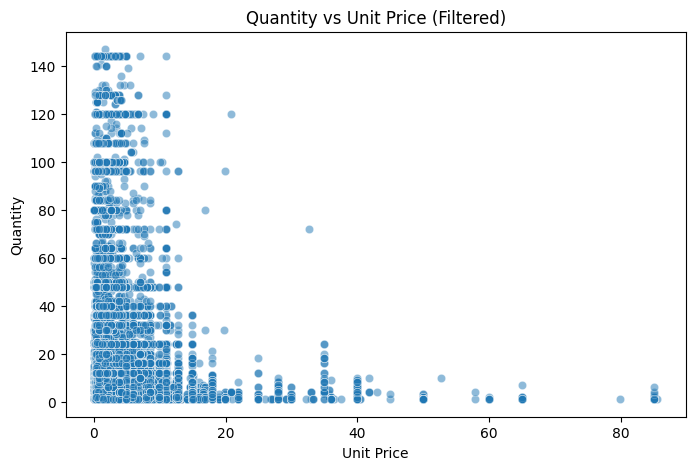

In [21]:
filtered_df = df_clean[(df_clean['UnitPrice'] < 100) & (df_clean['Quantity'] < 150)]

plt.figure(figsize=(8,5))
sns.scatterplot(x=filtered_df['UnitPrice'], y=filtered_df['Quantity'], alpha=0.5)

plt.title("Quantity vs Unit Price (Filtered)")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")

plt.show()

The scatter plot shows the relationship between unit price and purchase quantity. Most transactions involve low priced items and small quantities. There is no strong linear relationship between price and quantity, suggesting that customers do not necessarily buy more when prices are lower.

Filtering the data improves visualization and highlights the general purchasing pattern more clearly.

##5.6 Correlation Heatmap

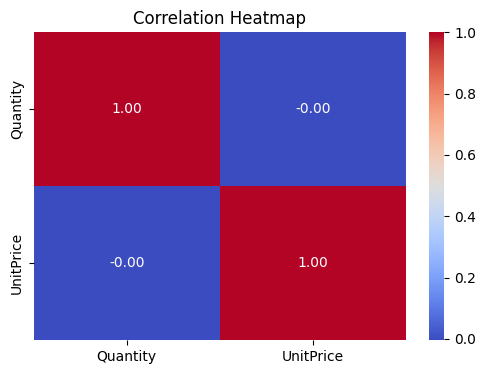

In [22]:
corr = df_clean[['Quantity', 'UnitPrice']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows the relationship between numerical variables such as quantity and unit price. The correlation coefficient is low, indicating that there is no strong linear relationship between these variables.

This suggests that pricing does not strongly influence the quantity purchased in this dataset.

##5.7 Monthly Sales Trend

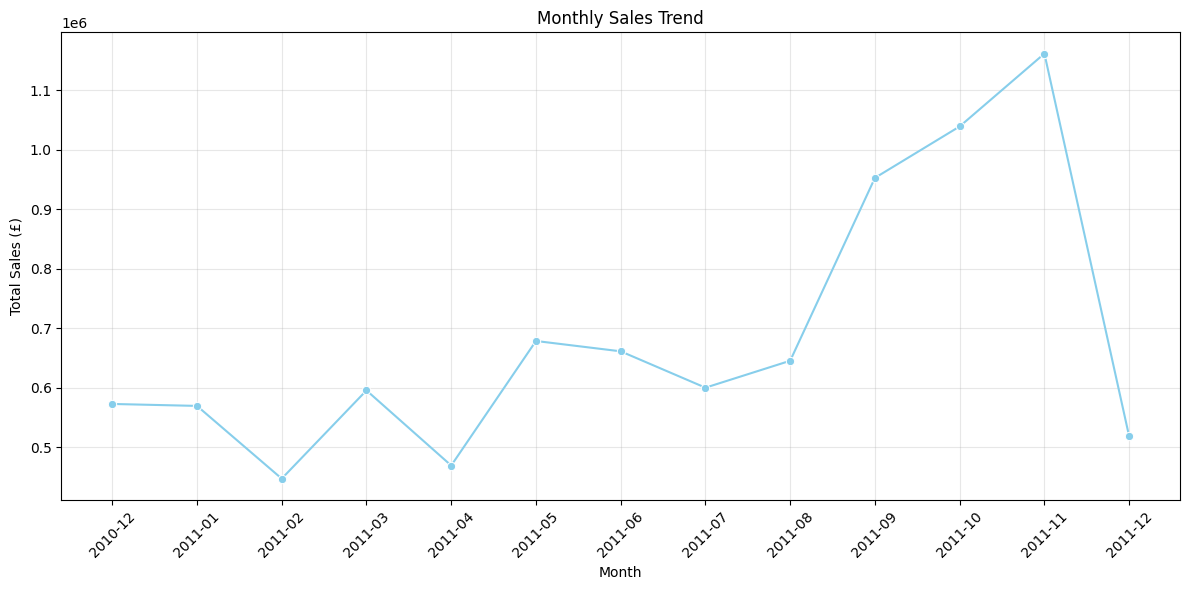

In [23]:

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']


df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(x='YearMonth', y='TotalPrice', data=monthly_sales, marker='o', color='skyblue')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The monthly sales trend shows how total revenue changes over time. Peaks and dips indicate seasonal variations, promotions, or special events affecting customer purchases.
Using the cleaned dataset ensures that only valid transactions are included, providing an accurate view of sales patterns. This visualization helps in inventory planning, marketing campaigns, and identifying high-demand periods.

#6.Data Transformation for Market Basket Analysis

In [24]:
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean_mb = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]
df_mb = df_clean_mb[['InvoiceNo','Description','Quantity']]

In [25]:

basket = df_mb.groupby(['InvoiceNo','Description'])['Quantity'].sum().unstack().fillna(0)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

/tmp/ipykernel_153/4059028212.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The transaction dataset is transformed into a format suitable for Market Basket Analysis. Each row represents a transaction (InvoiceNo), and each column represents a product. A value of 1 indicates that the product was purchased in that transaction, while 0 indicates it was not.
This binary matrix is required for the Apriori algorithm to identify frequent itemsets.

#7.Apply Apriori Algorithm

In [26]:
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)
frequent_itemsets.sort_values(by='support', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

,support,itemsets
192,0.106357,(WHITE HANGING HEART T-LIGHT HOLDER)
154,0.091895,(REGENCY CAKESTAND 3 TIER)
81,0.086337,(JUMBO BAG RED RETROSPOT)
124,0.074412,(PARTY BUNTING)
11,0.074196,(ASSORTED COLOUR BIRD ORNAMENT)
102,0.069501,(LUNCH BAG RED RETROSPOT)
166,0.061839,(SET OF 3 CAKE TINS PANTRY DESIGN )
139,0.059303,(POSTAGE)
95,0.056767,(LUNCH BAG BLACK SKULL.)
116,0.055526,(PACK OF 72 RETROSPOT CAKE CASES)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The Apriori algorithm identifies frequent itemsets, which are combinations of products that are commonly purchased together. A minimum support threshold of 2% is used to filter out rare combinations.
This step is essential for discovering meaningful patterns in customer purchasing behavior, which can inform product bundling and cross-selling strategies.

#8.Generate Association Rules

In [27]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

rules.sort_values('confidence', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
28,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.023527,0.037287,0.021045,0.894495,23.989564,1.0,0.020167,9.124846,0.981405,0.529172,0.890409,0.729447
29,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.024822,0.042251,0.021045,0.847826,20.066300,1.0,0.019996,6.293778,0.974350,0.457210,0.841113,0.672955
7,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030002,0.037287,0.024822,0.827338,22.188466,1.0,0.023703,5.575714,0.984468,0.584498,0.820651,0.746520
22,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.030002,0.042251,0.023527,0.784173,18.559754,1.0,0.022259,4.437569,0.975384,0.482835,0.774651,0.670503
11,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.037287,0.042251,0.029193,0.782923,18.530185,1.0,0.027617,4.412029,0.982675,0.579850,0.773347,0.736928
5,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.034265,0.040794,0.024984,0.729134,17.873424,1.0,0.023586,3.541254,0.977547,0.498922,0.717614,0.670784
27,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.029193,0.030002,0.021045,0.720887,24.027846,1.0,0.020169,3.475290,0.987201,0.551627,0.712254,0.711163
31,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.030002,0.029193,0.021045,0.701439,24.027846,1.0,0.020169,3.251619,0.988024,0.551627,0.692461,0.711163
10,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.042251,0.037287,0.029193,0.690932,18.530185,1.0,0.027617,3.114894,0.987768,0.579850,0.678962,0.736928
3,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.033240,0.037988,0.022879,0.688312,18.119023,1.0,0.021617,3.086454,0.977294,0.473214,0.676004,0.645292


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

The generated association rules identify relationships between products that are frequently purchased together.
Each rule includes support, confidence, and lift:
Support: The proportion of transactions containing the itemset.
Confidence: How often the rule is true.
Lift: How much more likely the products are purchased together than expected by chance.
Rules with a lift greater than 1 indicate strong positive associations and can be used for product bundling, cross-selling, and marketing strategies.

#9. Advanced Visualization
##9.1 Rule Quality Scatter Plot

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

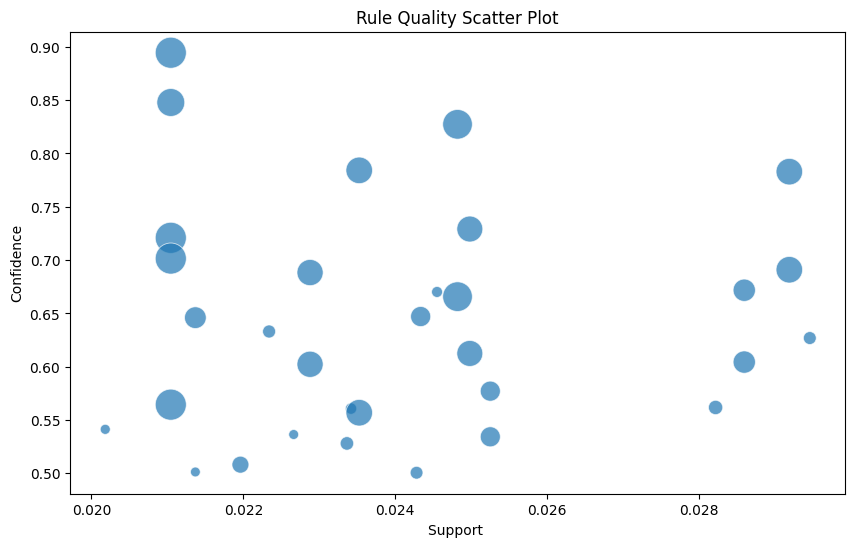

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    sizes=(50, 500),
    data=rules,
    legend=False,
    alpha=0.7
)

plt.title('Rule Quality Scatter Plot')
plt.xlabel('Support ')
plt.ylabel('Confidence')
plt.show()


1.Support
-Support measures how frequently the itemset appears in all transactions.
-For example, a support of 0.023 means that this combination of items appears in 2.3% of all transactions.
-High support indicates a common pattern, while low support may indicate a niche but strong correlation.
2.Confidence
-Confidence measures the reliability of a rule 𝐴→𝐵，i.e., the probability that B is purchased given that A is purchased.
-A confidence of 0.89 means that 89% of the time when item A is bought, item B is also bought.
-This tells us how trustworthy the rule is for predicting customer behavior.
3.Lift
-Lift measures how much more likely items A and B occur together than if they were independent.
-Lift > 1 indicates a positive correlation; the higher the lift, the stronger the association.
-For example, a lift of 20 means that items A and B are 20 times more likely to be bought together than expected by chance.
4.Rule Quality Scatter Plot
-X-axis (Support): Shows how frequent the rules are in the dataset.
-Y-axis (Confidence): Shows how reliable each rule is.
-Bubble size (Lift): Highlights the strength of the association relative to independence.
-This visualization allows us to quickly identify high-value rules: those with moderate-to-high support, high confidence, and large lift.
-It is especially useful in retail to target product bundling, promotions, or cross-selling opportunities.
5.Additional Notes
Some rules appear in both directions (A → B and B → A); this is normal.
Rules with low support but high confidence and lift may reveal niche but strong associations worth considering.

Using this analysis, businesses can make data-driven decisions about product placement and marketing strategies.

##9.2 Top Rules Table

In [33]:
from IPython.display import display
import pandas as pd

top_rules = rules.sort_values(by=['lift', 'confidence'], ascending=False).head(10)

top_rules_table = top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()

top_rules_table['antecedents'] = top_rules_table['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
top_rules_table['consequents'] = top_rules_table['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

top_rules_table['support'] = top_rules_table['support'].astype(float)
top_rules_table['confidence'] = top_rules_table['confidence'].astype(float)
top_rules_table['lift'] = top_rules_table['lift'].astype(float)

print("Top 10 Association Rules (Readable Format):")
display(top_rules_table)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 10 Association Rules (Readable Format):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
31,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.021045,0.701439,24.027846
27,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.021045,0.720887,24.027846
28,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.021045,0.894495,23.989564
30,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.021045,0.564399,23.989564
7,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024822,0.827338,22.188466
8,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024822,0.665702,22.188466
29,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.021045,0.847826,20.066300
22,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.023527,0.784173,18.559754
21,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.023527,0.556833,18.559754
11,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029193,0.782923,18.530185


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

1.Purpose of Top Rules Table
-It highlights the most valuable association rules discovered by the Apriori algorithm.
-Focuses on rules with high lift, high confidence, and reasonable support.
2.Columns Explained
-Antecedents → Consequents: Shows the “if-then” relationship of items.
-Support: Frequency of the itemset in all transactions.
-Confidence: Likelihood that consequents are bought when antecedents are bought.
-Lift: Strength of the association relative to independence.
3.Interpretation
-Rules with high confidence and high lift are strong, reliable, and actionable for marketing strategies.
-This table allows managers to easily identify which product combinations to promote, bundle, or cross-sell.

##9.3 Product Association Network

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

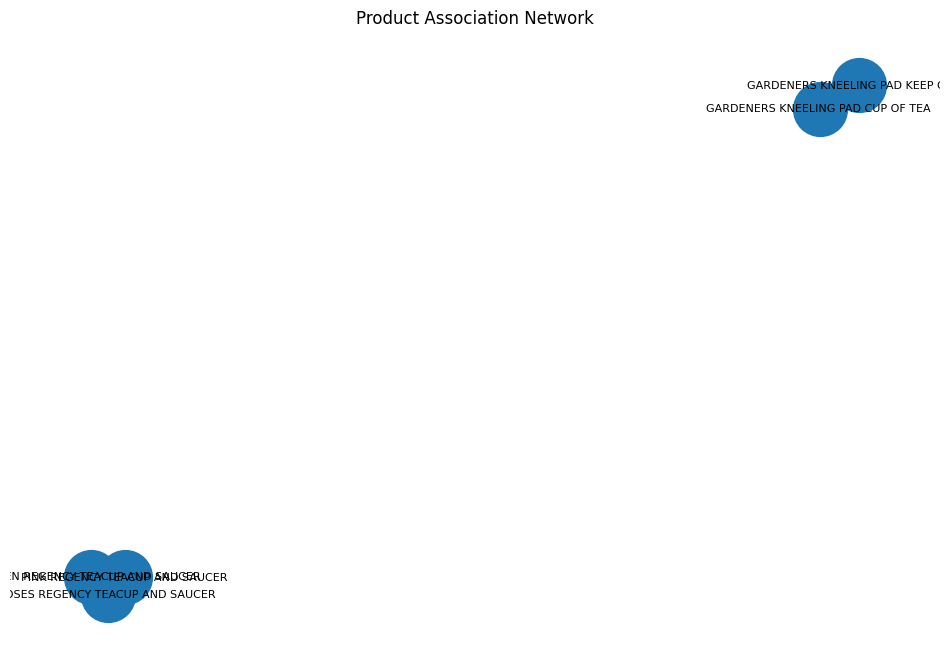

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [30]:
import networkx as nx
import matplotlib.pyplot as plt

filtered_rules = rules[(rules['lift'] > 5) & (rules['confidence'] > 0.7)]
G = nx.DiGraph()
for _, row in filtered_rules.iterrows():
  for antecedent in row['antecedents']:
    for consequent in row['consequents']:
      G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.4, iterations=100)
nx.draw_networkx_nodes(G, pos, node_size=1500)
edges = G.edges(data=True)
nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    width=[d['weight']*0.1 for (_,_,d) in edges],
    alpha=0.7,
    arrows=True
)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title('Product Association Network')
plt.axis('off')
plt.show()



The product association network visualizes relationships between items using a graph structure, where:

Nodes represent individual products

Edges (arrows) represent association rules (A → B)

Edge thickness reflects the strength of the relationship (lift)

This visualization provides a more intuitive understanding of how products are connected compared to tables.

Insights and Interpretation

Strongly connected nodes indicate products that are frequently purchased together.

Clusters of products may reveal natural groupings, such as complementary items or product bundles.

High-lift edges highlight particularly strong associations that may not be obvious from support alone.

Business Value

Helps identify cross-selling opportunities

Supports product bundling strategies

Improves store layout and recommendation systems

#10.Interpretation
The association rule analysis reveals several meaningful product relationships.

For example, certain decorative items frequently co-occur in customer purchases, suggesting complementary purchasing behavior.

Rules with lift values greater than 1 indicate that the co-occurrence of these items is stronger than random chance.

These findings support the discovery question regarding which products are frequently purchased together.

Such insights could inform product bundling strategies, cross-selling recommendations, and store layout optimization.

#11.Connection to Discovery Questions
This analysis addresses the discovery question:

"Which products are frequently purchased together in this retail dataset?"
The top association rules indicate that certain products are highly likely to be purchased together. For example: Customers who purchase one type of teacup are highly likely to purchase matching items from the same collection. Many of the discovered rules reflect complementary products, rather than random associations. Most rules are not surprising, as they involve related or matching items. However, they are still valuable because they confirm consistent purchasing behavior and can be used for: Product bundling Cross-selling strategies Recommendation systems

#12.Next Steps (M3)
Future work will extend the analysis by applying additional mining techniques:

• Customer segmentation using clustering algorithms (K-Means and DBSCAN)

• Anomaly detection using Isolation Forest and Local Outlier Factor

These methods will help identify natural customer segments and detect unusual purchasing behavior.